## Frank2D GPU 
### Description
This algorithm is the GPU version of the CPU Frankenstein2D optimized algorithm version.


#### Imports 

In [1]:
import os
import sys
import time
import matplotlib.pyplot as plt
import time

In [2]:
import cupy as cp

In [3]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [4]:
#frank2d
from frank2d_gpu.frank2d_gpu import Frank2D
from frank2d_gpu.geometry import Geometry
from frank2d_gpu.fourier2d_gpu import FourierTransform2D
from frank2d_gpu.preprocess_vis_gpu import Gridding
from frank2d_gpu.plot_gpu import Plot
from frank2d_gpu.constants import rad_to_arcsec, deg_to_rad
from frank2d_gpu.posterior_optimization_gpu import MAPEstimator

## Data

In [5]:
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [6]:
data = Elias27

# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

In [7]:
best_Elias27 = {'m': -3.2974333966979135, 'c': 316124419471722.0, 'l': 44039.61619138731}
best_AS209 = {'m': -1.3620910958135282, 'c': 4681.066458997977, 'l': 72454.26959113294}

In [8]:
best_AS209_2 = {'m': -0.5965374600481936, 'c': 0.24061104355821353, 'l': 65964.28945333029}
best_Elias27_2 = {'m': -2.0397167161810477, 'c': 33723199.469468266, 'l': 34841.20905181663}


In [9]:
kernel_params =  {'m': -2, 'c': 1e8, 'l': 7e4}


In [10]:
dir = "./../../data/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

In [11]:
# load data
data = cp.load(data_file)
u, v, Re, Imag, Weights = data["u"], data["v"], data["Re"], data["Im"], data["w"]
Vis = Re + Imag*1j

In [12]:
N = 300

In [13]:
geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, rout, geom)

In [14]:
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}

## Run Frank2D

In [15]:
print(uvtable['u'].dtype, type(uvtable['u']))

float64 <class 'cupy.ndarray'>


In [16]:
frank2d.process_vis(uvtable)

Setting gridded data...


In [17]:
print(frank2d.gridded_data['vis'].dtype, type(frank2d.gridded_data['vis']))

complex128 <class 'cupy.ndarray'>


In [35]:
best_params = best_Elias27_2

In [22]:
frank2d.fit(kernel_params = best_params, rtol = 1e-8 )

Setting GP Kernel Wendland...
Creating sparse linear system...
--> time kernel = 0.02  min |  1.35 seconds
--> times building system = 0.02  min |  1.44 seconds
Solving linear system...
Final tolerance :  0.5684907757598308
.... iteration:  0
                        -> actual tol:  56849077.57598308 vs  0.5684907757598308
.... iteration:  1
                        -> actual tol:  21714281.037881035 vs  0.5684907757598308
.... iteration:  2
                        -> actual tol:  4222158.301002746 vs  0.5684907757598308
.... iteration:  3
                        -> actual tol:  3512525.8557345537 vs  0.5684907757598308
.... iteration:  4
                        -> actual tol:  3531595.1758565633 vs  0.5684907757598308
.... iteration:  5
                        -> actual tol:  3071104.9792248574 vs  0.5684907757598308
.... iteration:  6
                        -> actual tol:  2863053.7555378536 vs  0.5684907757598308
.... iteration:  7
                        -> actual tol:  4090624.8535

#### cuda

In [39]:
n_devs = cp.cuda.runtime.getDeviceCount()
n_devs

1

In [40]:
# Dispositivo activo (id)
device_id = cp.cuda.runtime.getDevice()
print("Dispositivo activo (ID):", device_id)

# Propiedades (nombre, memoria, etc.)
props = cp.cuda.runtime.getDeviceProperties(device_id)
print("Nombre GPU:", props['name'])

Dispositivo activo (ID): 0
Nombre GPU: b'NVIDIA RTX A5000'


In [41]:
dev = cp.cuda.Device(device_id)
print("Memoria total (bytes):", dev.mem_info[1])
print("Memoria libre (bytes):", dev.mem_info[0])

Memoria total (bytes): 25409683456
Memoria libre (bytes): 19147128832


### Plot

In [23]:
import numpy as np

In [24]:
vis_gridded = frank2d.visibility_model

In [25]:
FT = frank2d._FT

In [26]:
vis_gridded = vis_gridded.get()

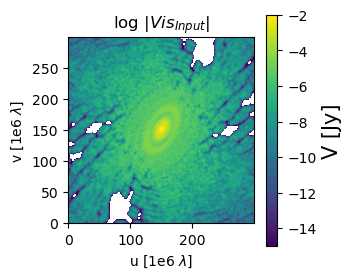

In [27]:
plt.figure(figsize = (3, 3))
plt.imshow(np.log(np.abs(vis_gridded.reshape(FT._Nx, FT._Ny))), origin='lower', vmin=-15, vmax=-2)
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{Input}$|')
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)

In [28]:
Plot_ = Plot(frank2d, geom)

In [29]:
uvtable_cpu = {key: uvtable[key].get() for key in uvtable}

In [30]:
uvtable_gridded_cpu = {key: frank2d.gridded_data[key].get() for key in frank2d.gridded_data}

In [31]:
u_d, v_d, _ = geom.deproject(u, v)

uvtable_gridded_cpu['u'] = u_d
uvtable_gridded_cpu['v'] = v_d

In [36]:
params = {'m': best_params['m'], 'c': best_params['c']}

In [37]:
ME = MAPEstimator(frank2d._Rmax,  frank2d._Geometry)
frank2d.set_MAP_estimator(ME)

Setting MAP estimator...


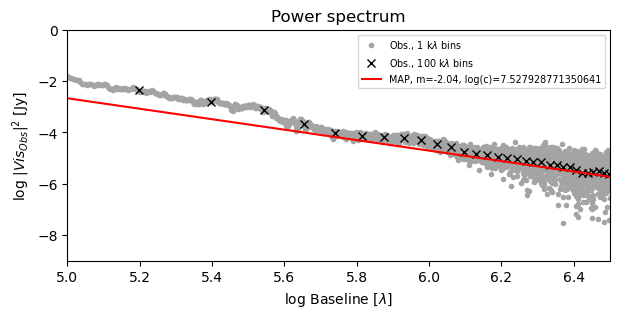

In [38]:
Plot_.MAP_power_spectrum(data = uvtable_cpu, params = params)

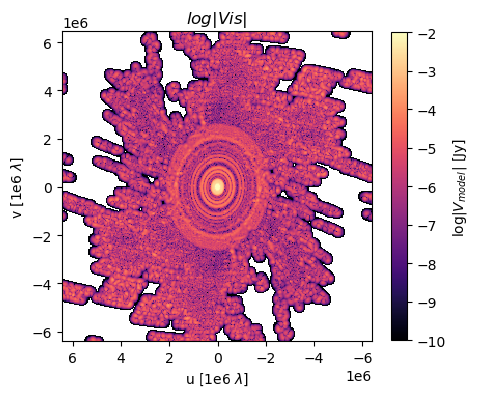

In [26]:
Plot_AS209.visibility(fig_size = 5, kind = 'model')

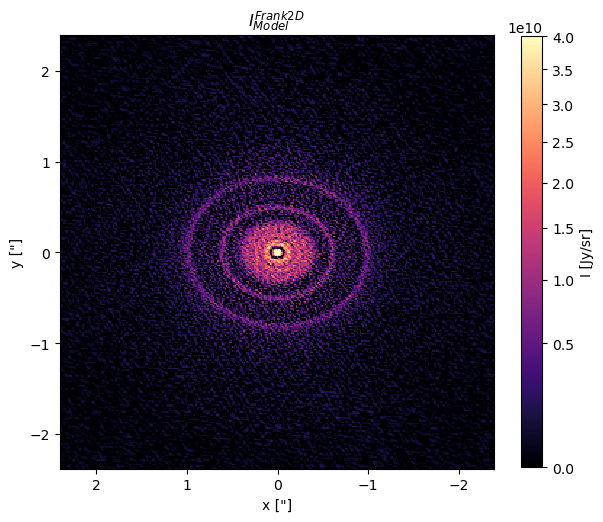

In [27]:
Plot_AS209.intensity(fig_size = 7, vmax = 4e10, gamma = 0.6, title = r'$I_{Model}^{Frank2D}$')

Performing 1D Frank fit...


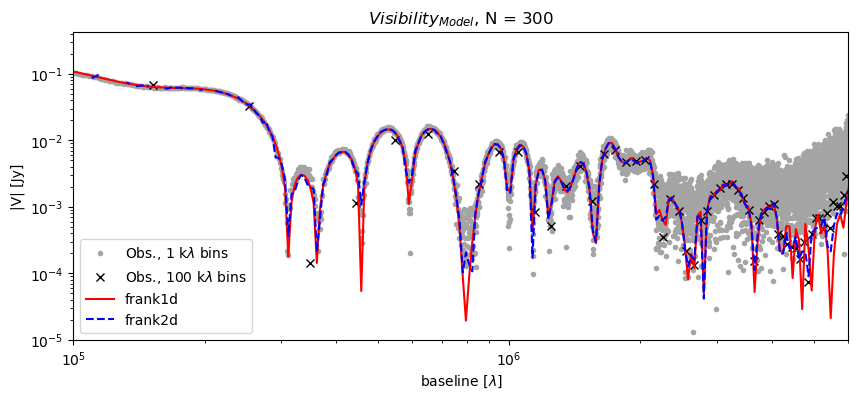

In [ ]:
Plot_AS209.visibility_profile(input = uvtable, weighted = True, frank1d = True)

Performing 1D Frank fit...


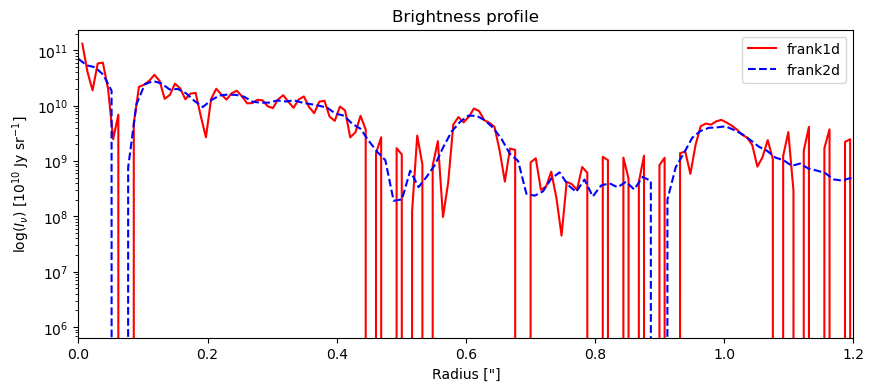

In [ ]:
Plot_AS209.intensity_profile(clean = False)

In [ ]:
dir_fits =  dir
disk_fits = disk_name + '_continuum.fits'
fits_file = dir_fits + disk_fits

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.


Clean beam: 0.038216292858108 x 0.036224924027904 arcsec
Performing 1D Frank fit...


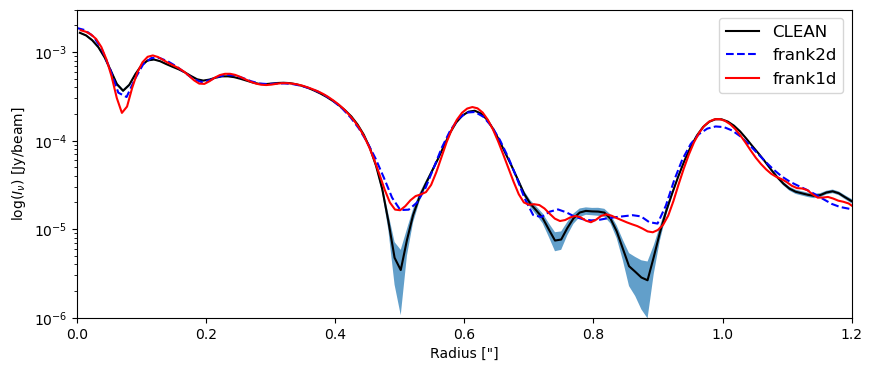

In [ ]:
Plot_AS209.intensity_profile(clean = True, fits_file = fits_file)

## Best

In [ ]:
frank2d.search_MAP()

In [ ]:
frank2d.MAP